![banner](../../../docs/figs/brand_identity/banner.png)

# Week 3: Python Data Structures

## Lesson overview

Starting with a small example about people and ages, practise storing and viewing data with lists, tuples, dictionaries, NumPy, and pandas. Finish by plotting several common charts.

**By the end, you can:** choose a data structure for a task; read rows, columns, and values in a table; and describe what bar, line, and scatter plots show.

**Before you begin:** The example data is written in the notebook, so no download is needed. Run cells in order. The CSV cell creates a file in the current working directory.

<p align="center"><img src="../figs/data_to_chart.svg" alt="Three separate notebook examples: a Python person dictionary, a pandas people table, and an A-to-D bar chart" width="100%"><br><em>Figure 1. Read each representation using the values in its own code cell; the chart uses a different example dataset from the table.</em></p>

**Use the figure:** Find `person["age"]`, locate Bob's age in the DataFrame, and then identify the largest bar. These are three distinct questions, not consecutive transformations of one dataset.


## Why this example matters

A dataset moves between Python collections, numeric arrays, tables, and charts. Choosing a representation determines which questions are easy to ask and which mistakes are easy to make.

**Inputs and requirements:** Python, NumPy, pandas, and matplotlib; examples are created in the notebook, so no account or download is required.

**Route through the lesson:** Store a small record → compare list/tuple/dictionary access → use NumPy for numeric operations → inspect a DataFrame → choose and read a chart.

**As you work:** Before each model or plot cell, predict one result. After it runs, describe one observation, identify its source, and name one limitation.


## Goal: represent and inspect a small dataset

Lists, tuples, and dictionaries represent different kinds of records; NumPy arrays support numeric operations; pandas tables organize observations by rows and columns. This notebook builds from small examples to inspectable tabular data. Outputs appear inline; no external data or credentials are needed.


## 1. Python Data Structures Basics

Run the list, tuple, and dictionary examples. Lists are accessed by position and dictionaries by name; check the output to confirm what you retrieved.

### Choose a structure by how you need to use the data

| Structure | Visual idea | Best for | Example access | Can change? |
|---|---|---|---|---|
| List | `[item, item, item]` | Ordered collection | `items[0]` | Yes |
| Tuple | `(x, y)` | Fixed group of values | `point[0]` | No |
| Dictionary | `{key: value}` | Named lookup | `person["name"]` | Yes |

Use the method documentation as a guide: `.append(value)` adds one item to a list; `.get(key, default)` safely looks up a dictionary entry; NumPy `.mean(array)` summarizes numeric values; pandas `.loc[label]` selects by label and `.iloc[position]` selects by integer position.

In [1]:
# List: ordered, changeable, allows duplicates
# A list is ordered, changeable, and allows duplicates.

# - Access elements by index (starting from 0)
# - Change elements by index
# - Add elements with `.append()`
# - Remove elements with `.remove()`
# - Get length with `len()`

fruits = ["apple", "banana", "cherry"]
print("First fruit:", fruits[0])      # Access first element
print("Last fruit:", fruits[-1])      # Access last element

# Change second fruit
fruits[1] = "blueberry"
print("Changed list:", fruits)

# Add a fruit
fruits.append("pineapple")
print("After append:", fruits)

# Remove a fruit
fruits.remove("apple")
print("After remove:", fruits)

# Length of list
print("Number of fruits:", len(fruits))

First fruit: apple
Last fruit: cherry
Changed list: ['apple', 'blueberry', 'cherry']
After append: ['apple', 'blueberry', 'cherry', 'pineapple']
After remove: ['blueberry', 'cherry', 'pineapple']
Number of fruits: 3


In [2]:
# Tuple: ordered, unchangeable
# A tuple is ordered and unchangeable (immutable).
# Access elements by index (like lists)
# Tuples cannot be changed after creation

coordinates = (10.0, 20.0)
print("First coordinate:", coordinates[0])

# Trying to change a tuple element will cause an error:
# coordinates[0] = 15.0  # Uncommenting this line will cause an error!

First coordinate: 10.0


In [3]:
# Dictionary: key-value pairs
# A dictionary stores values using keys.  
# To get a value from a dictionary, use the key inside square brackets `[]` or with `.get()`.
person = {"name": "Alice", "age": 22}
print("Name:", person["name"])   # Access value by key
print("Age:", person.get("age")) # Another way to get value

person["city"] = "New York" # Add a new key-value pair
person["age"] = 23 # Change an existing value
print("City:", person["city"]) # Another way to get value
print("Age:", person.get("age")) # Another way to get value

# Why this matters: Pandas and NumPy build on these ideas

Name: Alice
Age: 22
City: New York
Age: 23


## 2. NumPy Basics

Check the array shape and dimensions, then run the calculation. The shape tells you how many values there are in each direction.

### What is NumPy?

NumPy (Numerical Python) is a Python library used for fast numerical operations.

- It allows you to work with large arrays and matrices.
- It's much faster and more efficient than Python lists for math operations.
- It is the foundation for many scientific libraries in Python (like Pandas, Scikit-learn, etc).

Why not just use lists?
- Lists are flexible, but slow for large-scale calculations.
- NumPy arrays use less memory and support powerful vectorized operations (doing math on many values at once).

In [4]:
import numpy as np

# Create a NumPy array from a list
a = np.array([1, 2, 3, 4])
print("Array:", a)

# Basic operations
print("Mean:", np.mean(a))
print("Median:", np.median(a))
print("Sum:", np.sum(a))
print("Max:", np.max(a))
print("Min:", np.min(a))
print("Add 10:", a + 10)

Array: [1 2 3 4]
Mean: 2.5
Median: 2.5
Sum: 10
Max: 4
Min: 1
Add 10: [11 12 13 14]


In [5]:
# Create arrays with ranges
# np.arange(start, stop, step)

# - `start`: The first value (included)
# - `stop`: The end value (not included)
# - `step`: The amount to increase each time

range_array = np.arange(0, 10, 2)
print("Range array:", range_array)

Range array: [0 2 4 6 8]


In [6]:
# Shape and dimension

# Data type (dtype): tells what kind of data the array holds
print("Data type:", a.dtype)

# Number of dimensions (ndim): tells how many axes or directions the array has
print("Number of dimensions:", a.ndim)

# Shape: size of each dimension (length along each axis)
print("Shape:", a.shape)

Data type: int64
Number of dimensions: 1
Shape: (4,)


## 3. Pandas Basics

Each table row is one record and each column is one kind of information. First inspect the column names and first few rows, then retrieve a value by position or column name.

### What is Pandas?

Pandas is a powerful Python library for working with tabular data (data in rows and columns).

- It helps you read, organize, and analyze data easily.
- It is widely used in data science, machine learning, and data analysis.
- Main data structures in pandas are:
  - **Series**: a 1D labeled array (like a column)
  - **DataFrame**: a 2D labeled table (like an Excel spreadsheet)


In [7]:
import pandas as pd

# Create a Series (1D labeled array)
s = pd.Series([10, 20, 30, 40], index=["a", "b", "c", "d"])
s # display in jupyter notebook

a    10
b    20
c    30
d    40
dtype: int64

- Use `.iloc[position]` to get the value by integer position (starts at 0).  
- Use `.loc[label]` to get the value by the index label.

In [8]:
# Access value by position (integer index)
print("\nValue at position 0:", s.iloc[0])  # 10

# Access value by label (index name)
print("Value with label 'c':", s.loc["c"])  # 30


Value at position 0: 10
Value with label 'c': 30


In [9]:
# Create a DataFrame from a dictionary
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
    "City": ["New York", "Paris", "London"]
}
df = pd.DataFrame(data)
df # display in jupyter notebook

,Name,Age,City
0,Alice,25,New York
1,Bob,30,Paris
2,Charlie,35,London


In [10]:
# Access columns
df["Name"]

0      Alice
1        Bob
2    Charlie
Name: Name, dtype: object

In [11]:
# Access a row by index (iloc)
df.iloc[0]

Name       Alice
Age           25
City    New York
Name: 0, dtype: object

In [12]:
# Access a single value by row and column
print("\nValue at row 0, column 'Age':", df.loc[0, "Age"])    # Using label-based .loc
print("Value at row 1, column 'City':", df.iloc[1, 2])        # Using position-based .iloc


Value at row 0, column 'Age': 25
Value at row 1, column 'City': Paris


### Summary of ways to access data:

Use this summary to choose how to access data: `.iloc` uses a position, while `.loc` uses a label.

In [13]:
# Basic statistics on a column (similar to numpy)
print(df["Age"].mean())
print(df["Age"].median())
print(df["Age"].max())
print(df["Age"].min())

30.0
30.0
35
25


In [14]:
# Filter rows where Age > 28
df[df["Age"] > 28]

,Name,Age,City
1,Bob,30,Paris
2,Charlie,35,London


In [15]:
# Add a new column
df["Salary"] = [70000, 80000, 90000]
df

,Name,Age,City,Salary
0,Alice,25,New York,70000
1,Bob,30,Paris,80000
2,Charlie,35,London,90000


In [16]:
# Saving a DataFrame to a CSV file (one of the most common data format)
df.to_csv("sample.csv", index=False)  # index=False means row numbers are not saved
print("\nDataFrame saved to 'output.csv'")


DataFrame saved to 'output.csv'


In [17]:
# Reading a CSV file into a DataFrame
df = pd.read_csv("sample.csv")  # Replace "sample.csv" with your file path
df.head() # showing the fisrt few ros of the dataframe

,Name,Age,City,Salary
0,Alice,25,New York,70000
1,Bob,30,Paris,80000
2,Charlie,35,London,90000


## 4. Data Visualization

Read the x-axis, y-axis, and legend first. Then decide whether the chart compares categories, change over time, or the relationship between two numbers.

**Pause and predict:** A bar chart compares categories, a line chart shows ordered change, and a scatter plot shows paired numeric values. Before each plot, name its axes; afterward, write one observation and one question the figure cannot answer from these data alone.


### What is Matplotlib?

Matplotlib is a popular Python library used for creating static, interactive, and animated visualizations.

- It helps you draw different types of charts and graphs.
- It is widely used in data analysis, science, and engineering.
- The most common module is `matplotlib.pyplot`, often imported as `plt`.
- You create plots step-by-step and then show them using `plt.show()`.

In [18]:
import matplotlib.pyplot as plt

# Data for plotting
labels = ['A', 'B', 'C', 'D']
values = [23, 45, 56, 78]

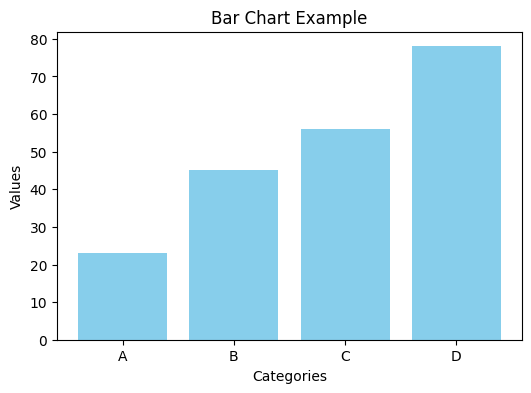

In [19]:
# 1. Bar Chart
plt.figure(figsize=(6,4))
plt.bar(labels, values, color='skyblue')
plt.title("Bar Chart Example")
plt.xlabel("Categories")
plt.ylabel("Values")
plt.show()

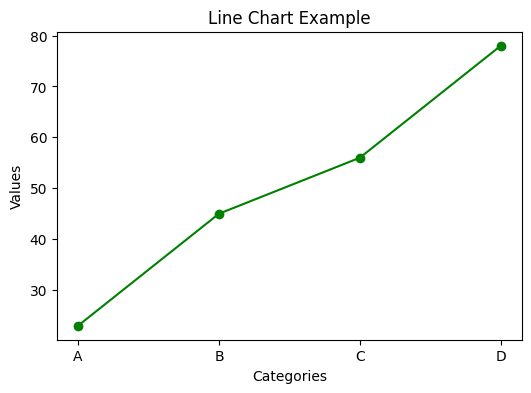

In [20]:
# 2. Line Chart
plt.figure(figsize=(6,4))
plt.plot(labels, values, marker='o', linestyle='-', color='green')
plt.title("Line Chart Example")
plt.xlabel("Categories")
plt.ylabel("Values")
plt.show()

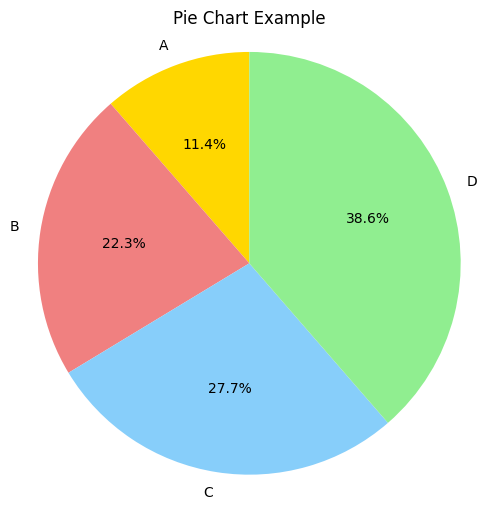

In [21]:
# 3. Pie Chart
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['gold', 'lightcoral', 'lightskyblue', 'lightgreen'])
plt.title("Pie Chart Example")
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular.
plt.show()

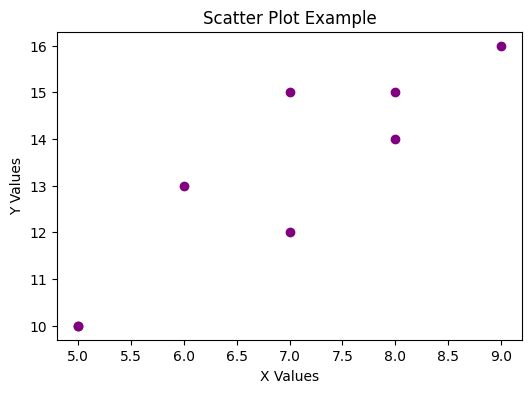

In [22]:
# 4. Scatter Plot (usually used to show the relationship of two variables)
x = [5, 7, 8, 5, 6, 7, 8, 9]
y = [10, 12, 15, 10, 13, 15, 14, 16]

plt.figure(figsize=(6,4))
plt.scatter(x, y, color='purple')
plt.title("Scatter Plot Example")
plt.xlabel("X Values")
plt.ylabel("Y Values")

# Save the figure to a PNG file
plt.savefig("scatter_plot.png")  # Saves to the current folder
plt.show()

## What to take away

Choosing a suitable data structure makes lookup and calculation clearer. **Try next:** Replace the example table with a small dataset of your own. **Limit:** A chart only displays the supplied data; it does not guarantee that the data is complete or accurate.